# Instacart Delivery Project by Dwayne Pringle

#### An Exploratory Data Analysis (EDA) Project

## Introduction
This project focuses on performing Exploratory Data Analysis (EDA) on Instacart delivery data to identify customer shopping trends and better understand ordering behavior. The goal is to clean, analyze, and visualize messy datasets to answer important business questions and uncover useful insights.

#### Work Plan
1. **Import Libraries**
    - Import Python libraries needed for analysis and visualization
2. **Explore the Data**
    - Load each CSV dataset
    - Review dataset structure, columns, and data types
3. **Clean the Data**
    - Identify and remove duplicate records
    - Identify and handle missing values
4. **Preprocess the Data**
    - Organize and prepare the datasets for analysis
    - Analyze relationships and patterns in the data
5. **Visualization and Questions**
    - Create charts and graphs
    - Answer business and customer behavior questions
6. **Feature Engineering**
    - Create new variables and metrics
    - Use filtering, grouping, counting, and aggregation to discover insights

In [292]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

In [293]:
# loading the orders.csv file into a DataFrame called df_orders
df_orders = pd.read_csv('./datasets/instacart_orders.csv', sep=';' )
df_orders.info()
df_orders.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1515936,183418,11,6,13,30.0
1,1690866,163593,5,5,12,9.0
2,1454967,39980,4,5,19,2.0
3,1768857,82516,56,0,20,10.0
4,3007858,196724,2,4,12,17.0


The Order DataFrame captures user shopping behavior on the Instacart online platform, representing detailed information about customer orders, including the hour of the day, day of the week, and the number of days between initial and subsequent orders. Each row corresponds to a unique customer order, identified by a user ID and an order ID, with columns detailing the specific time of purchase, number of items ordered, and the time gap since the last order. This structure allows for analysis of customer ordering patterns and frequency, providing insights into user behavior and shopping habits over time.

In [294]:
# loading the order_products.csv file into a DataFrame called df_order_products
df_product = pd.read_csv('./datasets/products.csv',sep=';')
df_product.info()
df_product.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


The Product DataFrame provides key details about each product, including its name, department, and aisle section, all associated with a unique product ID. This structure offers insight into how Instacart organizes and categorizes its products within the platform, allowing for better understanding of product classification and inventory management.

In [295]:
# loading the order_products.csv file into a DataFrame called df_order_products
df_aisles = pd.read_csv('./datasets/aisles.csv',sep=';')
df_aisles.info()
df_aisles.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


The Aisle DataFrame categorizes products based on their respective aisles, with each aisle representing a range of product options. The data is organized by unique identification numbers, providing insight into how products are grouped and organized within the aisles, facilitating efficient categorization and product placement within the store.

In [296]:
# loading the departments.csv file into a DataFrame called df_departments
df_departments = pd.read_csv('./datasets/departments.csv',sep=';')
df_departments.info()
df_departments.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 468.0+ bytes


,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


The Department DataFrame maps each product to its corresponding department within the store, providing the specific location of items to streamline order selection. This data helps optimize the picking process, enabling faster and more efficient order fulfillment for customer delivery.

In [297]:
# loading the order_products.csv file into a DataFrame called df_order_products
df_order_products = pd.read_csv('./datasets/order_products.csv',sep=';')
df_order_products.info(show_counts=True)
df_order_products.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4544171 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


,order_id,product_id,add_to_cart_order,reordered
0,2141543,11440,17.0,0
1,567889,1560,1.0,1
2,2261212,26683,1.0,1
3,491251,8670,35.0,1
4,2571142,1940,5.0,1


The Order product DataFrame tracks the products added to customer carts, including the quantity of each item and the frequency with which it is reordered. This data helps the company identify high-demand items, guiding inventory decisions to ensure popular products are kept in stock to meet customer needs.

## Manage Duplicates Values

### Find and Handle duplicates for `orders` data frame

In [298]:
# Check for duplicated orders
df_orders.duplicated().sum()

np.int64(15)

In [299]:
# Check for all orders placed Wednesday at 2:00 AM
wednesday_order_at_2am = df_orders[(df_orders['order_dow']== 3) & (df_orders['order_hour_of_day']== 2)]
print(wednesday_order_at_2am) 

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
4838     2766110   162084            41          3                  2   
5156     2190225   138285            18          3                  2   
15506     553049    58599            13          3                  2   
18420     382357   120200            19          3                  2   
24691     690242    77357             2          3                  2   
...          ...      ...           ...        ...                ...   
457013   3384021    14881             6          3                  2   
458816    910166   164782            18          3                  2   
459635   1680532   106435             6          3                  2   
468324    222962    54979            59          3                  2   
477526   2592344    46860            38          3                  2   

        days_since_prior_order  
4838                      16.0  
5156                      11.0  
15506                   

In [300]:
# Remove duplicate orders
df_orders = df_orders.drop_duplicates()

In [301]:
# Double check for duplicate rows
df_orders.duplicated().sum()

np.int64(0)

In [302]:
# Double check for duplicate order IDs only
df_orders.duplicated(subset=['order_id']).sum()

np.int64(0)

In the orders dataset, I identified 15 duplicate records, likely caused by multiple entries for the same order being logged at different stages of the order process or from different systems capturing the same transaction. To address this, I used the .drop_duplicates() method, which efficiently removes redundant rows, ensuring that only unique orders are represented in the dataset. This method was chosen because it is a simple and effective way to eliminate duplicates, preventing overcounting and ensuring accurate analysis of order-related metrics. The duplicates may have arisen from issues like order splitting, different teams recording data separately, or technical challenges like system sync errors.

### Find and Handle duplicates for `product` data frame

In [303]:
# Check for fully duplicate rows
df_product.duplicated().sum()

np.int64(0)

In [304]:
# Check for just duplicate product IDs
df_product.duplicated(subset='product_id', keep=False)

0        False
1        False
2        False
3        False
4        False
         ...  
49689    False
49690    False
49691    False
49692    False
49693    False
Length: 49694, dtype: bool

In [305]:
# Check for just duplicate product names (convert names to lowercase to compare better)
df_product['product_name'].str.lower()
df_product.duplicated(subset='product_name',keep=False)

0        False
1        False
2        False
3        False
4        False
         ...  
49689    False
49690    False
49691    False
49692    False
49693    False
Length: 49694, dtype: bool

In [306]:
# Check for duplicate product names that aren't missing
df_product['product_name'].notna().sum()

np.int64(48436)

In the products dataframe, no duplicate values were found, as confirmed by checking specific columns for duplications using appropriate methods like .duplicated(). Since there were no duplicates, no removal was necessary, which indicates that the dataset is well-structured and free from redundancy. The methods used were specifically tailored to detect duplicates and handle non-missing values, ensuring that the dataset was parsed correctly without any issues. This clean state of the dataframe suggests that the data import and processing steps were executed without error, maintaining the integrity of product records.

### Find and Handle duplicates for `departments` data frame

In [307]:
df_departments.duplicated().sum()

np.int64(0)

In the departments dataframe, no duplicate values were found, indicating that each department entry was unique. As a result, no action was needed to remove duplicates. The absence of duplicates suggests that the data was correctly structured, with each department represented only once, and no redundancy was present in the dataset. This likely reflects proper data entry and organization during the data collection process, ensuring that there were no errors in recording department information. The dataset’s integrity was maintained, allowing for accurate categorization and analysis without further cleaning or modification.

### Find and Handle duplicates for `aisles` data frame

In [308]:
df_aisles.duplicated().sum()

np.int64(0)

In the aisles dataframe, no duplicate values were found, indicating that each aisle entry was unique and properly recorded. As there were no duplicates, no removal or cleaning was necessary. The absence of redundancy suggests that the data was well-structured and correctly parsed during the data ingestion process, without any issues of repeated or erroneous entries. This likely reflects accurate data collection and organization, ensuring that each aisle was represented only once, which supports the integrity of the dataset for subsequent analysis or modeling.

### Find and Handle duplicates for `order_product` data frame

In [309]:
# Check for fullly duplicate rows
df_order_products.duplicated().sum()

np.int64(0)

In [310]:
# Double check for any other tricky duplicates
df_order_products.duplicated(subset= ['order_id','product_id']).sum()

np.int64(0)

In the order_product dataframe, no duplicate values were found, even when applying the .duplicated() method with parameter column subsets to check for potential tricky duplicates. Since no duplicates were detected, no removal or cleaning was necessary. This outcome suggests that the data is well-structured and that each order-product combination is unique, ensuring the integrity of the dataset. The absence of duplicates likely reflects careful data entry and processing, where each record was correctly captured and there were no issues with redundant or erroneous entries during data collection.

## Manage Missing Values

### Find and handle missing values for `product` data frame

In [311]:
df_product.isna().sum()

product_id          0
product_name     1258
aisle_id            0
department_id       0
dtype: int64

In [312]:
# Are all of the missing product names associated with aisle ID 100?
missing_product_asile = df_product[df_product['aisle_id']== 100]['product_name'].isna().sum()
print(missing_product_asile )

1258


In [313]:
# Are all of the missing product names associated with department ID 21?
missing_product_department = df_product[df_product['department_id']== 21]['product_name'].isna().sum()
print(missing_product_department)

1258


In [314]:
# What is this aisle and department?
combine_columns = df_product[(df_product['aisle_id'].isna()) & (df_product['department_id'].isna())]
print(combine_columns)

Empty DataFrame
Columns: [product_id, product_name, aisle_id, department_id]
Index: []


In [315]:
# Fill missing product names with 'Unknown'
df_product['product_name'] = df_product['product_name'].fillna(value='Unknown')
df_product.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   49694 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In the product_name column, the .isna() method revealed 1,258 missing values, which were then filled using the .fillna() method with the placeholder value ‘unknown’. This approach ensures that the dataset remains complete without dropping records, while clearly marking the missing values. The decision to fill with ‘unknown’ was made to avoid introducing assumptions about the missing data, while maintaining consistency. The missing values are likely the result of incomplete data entry, where product names were not provided or captured during the initial data collection process, possibly due to errors or omissions during the import or input stages.

### Find and Handle missing values for `orders` data frame

In [316]:
df_orders.isna().sum()

order_id                      0
user_id                       0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    28817
dtype: int64

In [317]:
# Are there any missing values where it's not a customer's first order?
df_orders['order_number'].notna().sum()

np.int64(478952)

In the orders dataframe, I identified 28,817 missing values out of a total of 450,148 entries. These missing values were neither removed nor imputed, as they likely reflect business rules where certain fields are intentionally left blank for specific types of orders (example optional or non-applicable information). Given that the majority of the data (478,952 non-missing values) was complete, retaining these missing values preserves the dataset's integrity without introducing unnecessary assumptions. The decision not to fill these values was made to avoid skewing the analysis, as imputing non-applicable data could lead to inaccurate or misleading insights.

### Find and Handle missing values for `order_products` data frame

In [318]:
df_order_products.isna().sum()

order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64

In [319]:
# What are the min and max values in this column?
min_value= df_order_products['add_to_cart_order'].min()
max_value= df_order_products['add_to_cart_order'].max()
print(f"Minimum Value:{min_value}, Maximum Value:{max_value}")

Minimum Value:1.0, Maximum Value:64.0


In [320]:
# Save all order IDs with at least one missing value in 'add_to_cart_order'
missing_order_id = df_order_products[df_order_products['add_to_cart_order'].isna()]['order_id']
print(missing_order_id)

737        2449164
9926       1968313
14394      2926893
16418      1717990
30114      1959075
            ...   
4505662    1800005
4511400    1633337
4517562     404157
4534112    1673227
4535739    1832957
Name: order_id, Length: 836, dtype: int64


In [321]:
# Do all orders with missing values have more than 64 products?
df_order_products[df_order_products['order_id'].isin(missing_order_id)].groupby('order_id').count().sort_values(by='product_id')

,product_id,add_to_cart_order,reordered
order_id,,,
9310,65,64,65
747668,65,64,65
888470,65,64,65
2621907,65,64,65
2170451,65,64,65
...,...,...,...
1959075,98,64,98
171934,104,64,104
2136777,108,64,108


In [322]:
# Replace missing values with 999 and convert column to integer type
df_order_products['add_to_cart_order'] = df_order_products['add_to_cart_order'].fillna(value='999')
df_order_products['add_to_cart_order'] = df_order_products['add_to_cart_order'].astype(int)
df_order_products.info(show_counts=True)
df_order_products.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype
---  ------             --------------    -----
 0   order_id           4545007 non-null  int64
 1   product_id         4545007 non-null  int64
 2   add_to_cart_order  4545007 non-null  int64
 3   reordered          4545007 non-null  int64
dtypes: int64(4)
memory usage: 138.7 MB


,order_id,product_id,add_to_cart_order,reordered
0,2141543,11440,17,0
1,567889,1560,1,1
2,2261212,26683,1,1
3,491251,8670,35,1
4,2571142,1940,5,1
5,2456893,21616,4,1
6,644579,12341,5,1
7,2231852,44925,10,1
8,3185766,36259,14,1
9,420019,23315,4,1


In the order_products dataframe, I identified 836 missing values in the add_to_cart_order column, which were imputed with the value 999 using the .fillna() method. Additionally, I converted the column from float to integer type to ensure consistency in the dataset. This approach was chosen to clearly flag the missing values while maintaining the integrity of the dataset for analysis. The use of 999 was deliberate to distinguish missing values from valid data and prevent misinterpretation. The missing values were likely caused by data collection errors, such as human mistakes or faulty data entry, where the sequence of items added to the cart was not recorded or inputted incorrectly.

## Anaylsis Data 

###  Verify that the `'order_hour_of_day'` and `'order_dow'` values in the `orders` tables are sensible (i.e. `'order_hour_of_day'` ranges from 0 to 23 and `'order_dow'` ranges from 0 to 6)

In [323]:
sensible_hours = df_orders[(df_orders['order_hour_of_day'] < 0) | (df_orders['order_hour_of_day'] > 23)]
print(f"Sensible values in 'order_hour_of_day': {sensible_hours}")

Sensible values in 'order_hour_of_day': Empty DataFrame
Columns: [order_id, user_id, order_number, order_dow, order_hour_of_day, days_since_prior_order]
Index: []


In [324]:
sensible_dow = df_orders[(df_orders['order_dow'] < 0) | (df_orders['order_dow'] > 6)]
print(f"Sensible values in 'order_dow': {sensible_dow}")

Sensible values in 'order_dow': Empty DataFrame
Columns: [order_id, user_id, order_number, order_dow, order_hour_of_day, days_since_prior_order]
Index: []


# Plotting Results and Questions

### What time of day do people shop for groceries?

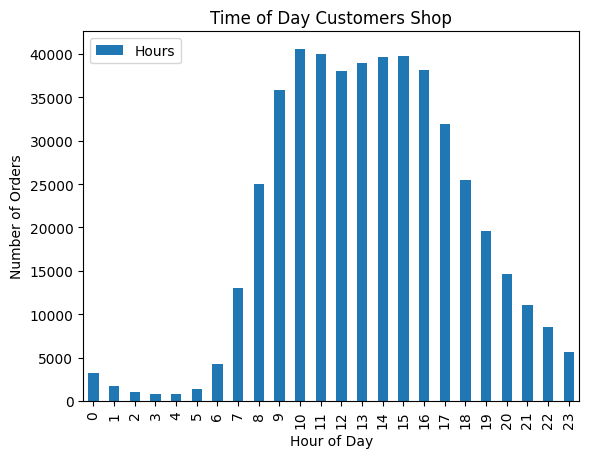

In [325]:
# grouping two columns and counting their values
hour_shopping = df_orders.groupby('order_hour_of_day')['order_number'].count()

# plotting a bar chart for the time of day customer shop
hour_shopping.plot(kind='bar')
plt.title('Time of Day Customers Shop')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Orders')
plt.legend(['Hours'],loc='upper left')
plt.show()

### What day of the week do people shop for groceries?

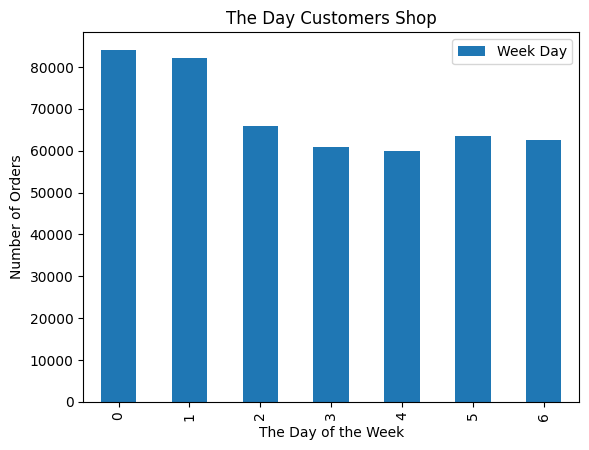

In [326]:
# grouping two columns and counting their values
day_of_shopping = df_orders.groupby('order_dow')['order_number'].count()

# plotting a bar chart for days customers shop
day_of_shopping.plot(kind='bar')
plt.title('The Day Customers Shop')
plt.xlabel('The Day of the Week')
plt.ylabel('Number of Orders')
plt.legend(['Week Day'], loc='upper right')
plt.show()

### How long do people wait until placing another order?

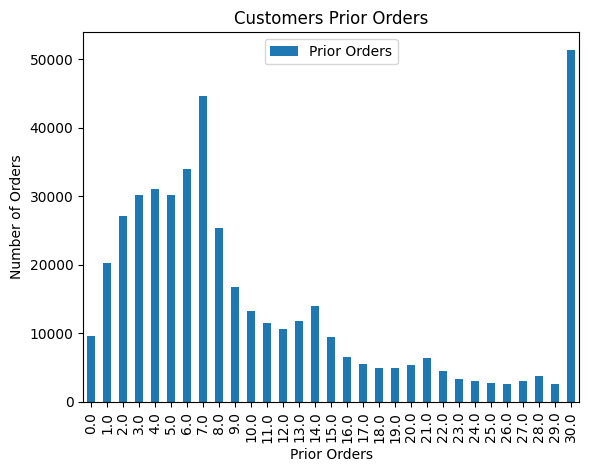

In [327]:
# grouping two columns and count their values
prior_shopping = df_orders.groupby('days_since_prior_order')['order_number'].count()

#plotting a bar chart for prior orders
prior_shopping.plot(kind='bar')
plt.title('Customers Prior Orders')
plt.xlabel('Prior Orders')
plt.ylabel('Number of Orders')
plt.legend(['Prior Orders'], loc='upper center')
plt.show()

### Is there a difference in `'order_hour_of_day'` distributions on Wednesdays and Saturdays? Plot the histograms for both days and describe the differences that you see.

In [328]:
# selecting different distributions on wednesday and saturdays
wednesdays = df_orders[df_orders['order_dow']== 3] 
saturdays = df_orders[df_orders['order_dow']== 6]

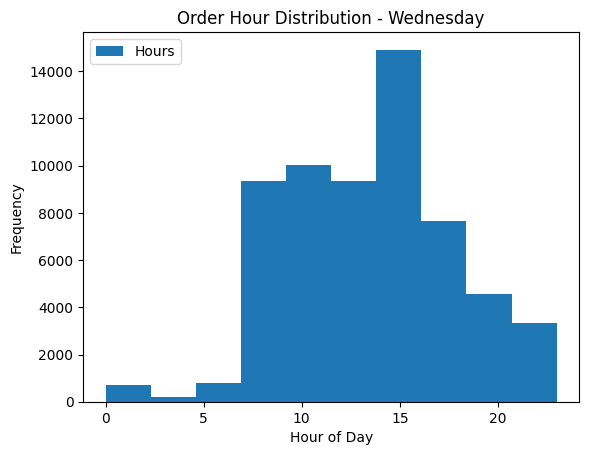

In [329]:
# plotting a histograms for hour of distribution on Wednesdays
plt.hist(wednesdays['order_hour_of_day'])
plt.title('Order Hour Distribution - Wednesday')
plt.xlabel('Hour of Day')
plt.ylabel('Frequency')
plt.legend(['Hours'], loc='upper left')
plt.show()

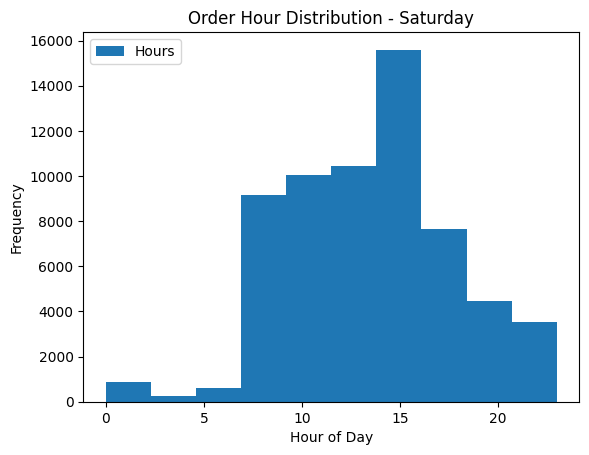

In [330]:
# plotting a histograms for hours of distribution on Saturdays
plt.hist(saturdays['order_hour_of_day'])
plt.title('Order Hour Distribution - Saturday')
plt.xlabel('Hour of Day')
plt.ylabel('Frequency')
plt.legend(['Hours'], loc='upper left')
plt.show()

### What's the distribution for the number of orders per customer?

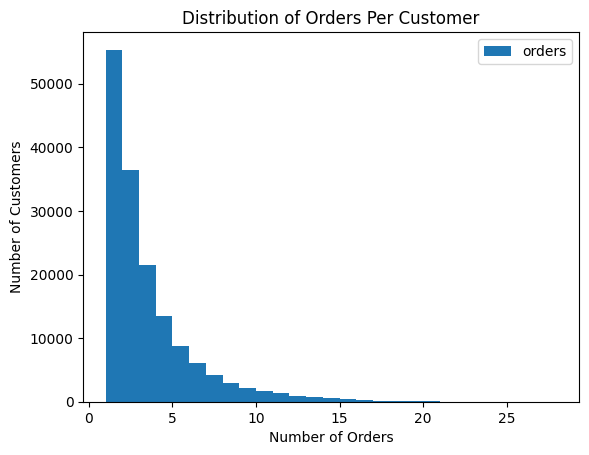

In [331]:
# Grouping two columns and counting their values 
dis_order = df_orders.groupby('user_id')['order_number'].nunique()

# Plotting a histogram for distribution of order per customer
dis_order.hist(bins=range(1, dis_order.max() + 1), grid=False)
plt.title('Distribution of Orders Per Customer')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')
plt.legend(['orders'], loc='upper right')
plt.show()

### What are the top 20 popular products (display their id and name)?

In [332]:
# finding the top value count (product mostly selected) for the top 20 products
top_20_products = df_product['product_id'].value_counts().head(20)

# creating a df for the top 20 products
top_20_products_df = df_product[df_product['product_id'].isin(top_20_products.index)] 

# identifying the top 20 products ID and Names
top_20_products_df[['product_id', 'product_name']]

,product_id,product_name
0,1,Chocolate Sandwich Cookies
1,2,All-Seasons Salt
2,3,Robust Golden Unsweetened Oolong Tea
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...
4,5,Green Chile Anytime Sauce
5,6,Dry Nose Oil
6,7,Pure Coconut Water With Orange
7,8,Cut Russet Potatoes Steam N' Mash
8,9,Light Strawberry Blueberry Yogurt
9,10,Sparkling Orange Juice & Prickly Pear Beverage


### How many items do people typically buy in one order? What does the distribution look like?

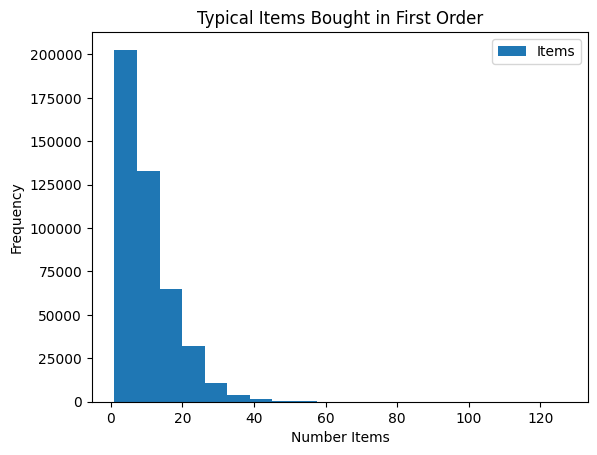

In [333]:
# Group by order id and count the items in each order 
items_per_order = df_order_products.groupby('order_id')['add_to_cart_order'].count()

# plotting a histogram for numbers of items
items_per_order.plot(kind='hist', bins=20, title='Typical Items Bought in First Order')
plt.xlabel('Number Items')
plt.ylabel('Frequency')
plt.legend(['Items'], loc='upper right')
plt.show()

In [334]:
# finding the average got items per order
avg_items = items_per_order.mean()
print(f"The avarage number of items per first order: {(avg_items).round()}")

The avarage number of items per first order: 10.0


### What are the top 20 items that are reordered most frequently (display their names and product IDs)?

In [335]:
# 1. Filter for reordered items and group by product_id to count reorders
product_reorder_counts = (
    df_order_products[df_order_products["reordered"] == 1]
    .groupby("product_id")
    .size()
    .reset_index(name="reorder_count")
)

# 2. Merge with df_product to attach the actual names of the products
#    Using drop_duplicates ensures we do not duplicate rows during the join
product_reorders_with_names = product_reorder_counts.merge(
    df_product[["product_id", "product_name"]].drop_duplicates(),
    on="product_id",
    how="inner",
)

# 3. Sort by reorder count from greatest to least and extract the top 20
top_20_reorders = product_reorders_with_names.sort_values(
    by="reorder_count", ascending=False
).head(20)

# 4. Display the results
print(top_20_reorders)

       product_id  reorder_count              product_name
18104       24852          55763                    Banana
9528        13176          44450    Bag of Organic Bananas
15368       21137          28639      Organic Strawberries
15936       21903          26233      Organic Baby Spinach
34407       47209          23629      Organic Hass Avocado
34828       47766          18743           Organic Avocado
20285       27845          16251        Organic Whole Milk
34725       47626          15044               Large Lemon
20375       27966          14748       Organic Raspberries
12193       16797          13945              Strawberries
19088       26209          13327                     Limes
16700       22935          11145      Organic Yellow Onion
18186       24964          10411            Organic Garlic
32792       45007          10076          Organic Zucchini
36219       49683           9538            Cucumber Kirby
20543       28204           8989        Organic Fuji App

### For each product, what proportion of its orders are reorders?

In [336]:
# adding cart order and reorder columns to find the proportion of reorders
gathered_portion = df_order_products['add_to_cart_order'].sum() + df_order_products['reordered'].sum()

# finding the total number of reorders
total_reorders = df_order_products['reordered'].sum()

# calculating the proportion of reorders
reordered_portion =  gathered_portion / total_reorders

# printing the proportion of reorders
print(f"The proportion of Reorders: {(reordered_portion).round()}%") 

The proportion of Reorders: 15.0%


### For each customer, what proportion of their products ordered are reorders?

In [337]:
# count the non-null values in the 'order_id' column of the df_order_products DataFrame
count_customers = df_order_products['order_id'].count()

# divide the count of customers by the total number of reorders to find the proportion of customers who reorder
customer_portion = count_customers / total_reorders

# printing the proportion of customers who reorder
print(f"The proportion of Customers reorders: {(customer_portion).round()}%")

The proportion of Customers reorders: 2.0%


### What are the top 20 items that people put in their carts first? 

In [338]:
# Filter for items that were added to the cart (add_to_cart_order == 1)
in_cart_first = df_order_products[df_order_products['add_to_cart_order']==1]

# merge the filtered DataFrame with df_product to get product names
top_items_first = in_cart_first.merge(df_product, on='product_id')

# Group by product_id and product_name, count the occurrences, sort by count, and get the top 20
top_20_items = top_items_first.groupby(['product_id', 'product_name']).size().sort_values(ascending=False).head(20)

# print the top 20 items that customers add to their cart first
print(top_20_items)

product_id  product_name               
24852       Banana                         15562
13176       Bag of Organic Bananas         11026
27845       Organic Whole Milk              4363
21137       Organic Strawberries            3946
47209       Organic Hass Avocado            3390
21903       Organic Baby Spinach            3336
47766       Organic Avocado                 3044
19660       Spring Water                    2336
16797       Strawberries                    2308
27966       Organic Raspberries             2024
44632       Sparkling Water Grapefruit      1914
49235       Organic Half & Half             1797
47626       Large Lemon                     1737
196         Soda                            1733
38689       Organic Reduced Fat Milk        1397
26209       Limes                           1370
12341       Hass Avocados                   1340
5785        Organic Reduced Fat 2% Milk     1310
27086       Half & Half                     1309
43352       Raspberries      